<Axes: >

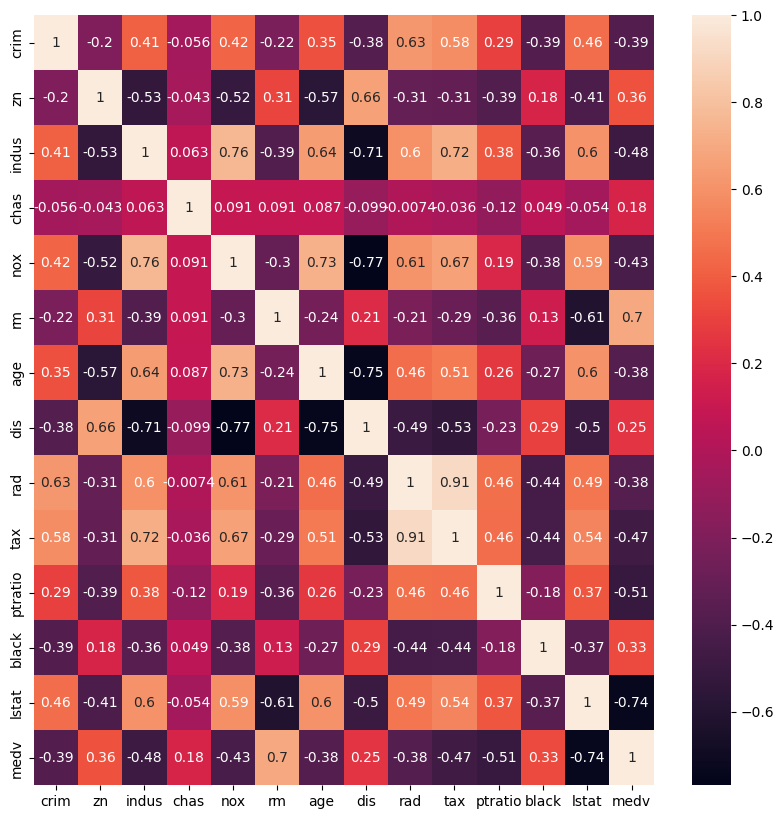

In [2]:
#libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, RidgeCV, Lasso
from sklearn.preprocessing import StandardScaler
# from sklearn.datasets import load_boston

#data
boston_df = pd.read_csv("c:/Users/bteba/Documents/GitHub/DataScience/database/Boston.csv")
#preview
boston_df.head()

#Exploration
plt.figure(figsize = (10, 10))
sns.heatmap(boston_df.corr(), annot = True)

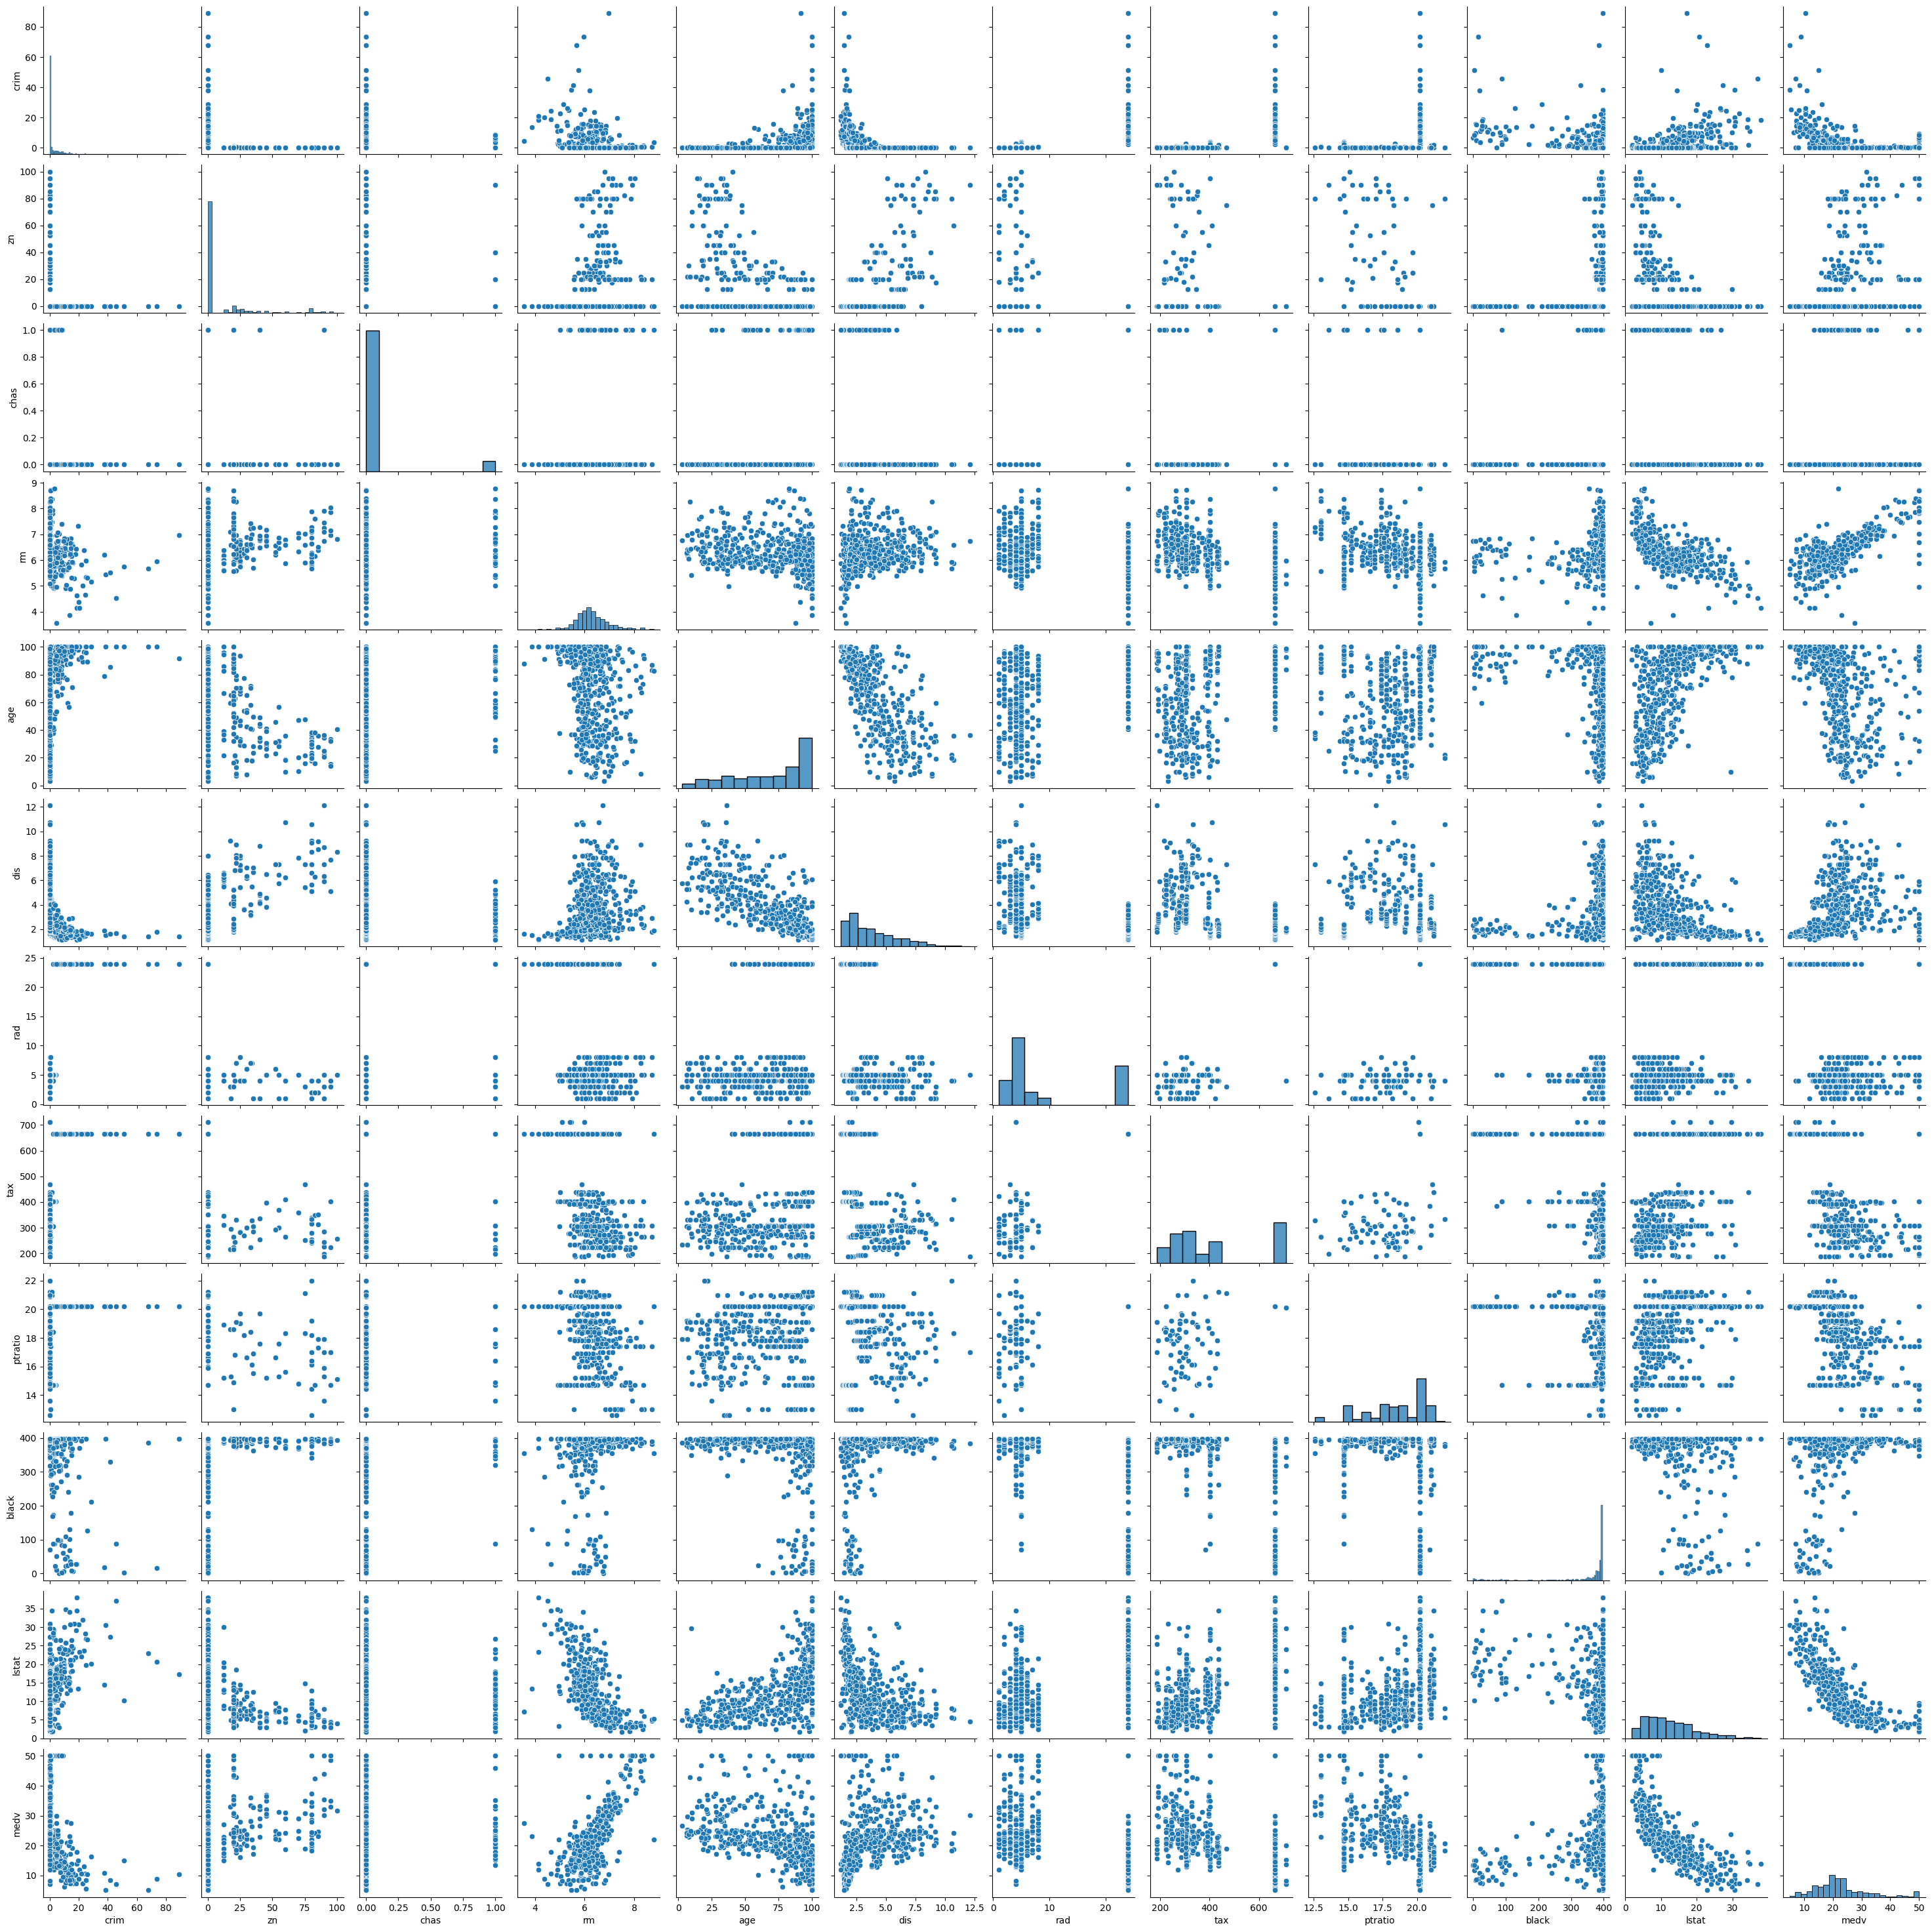

In [3]:
#There are cases of multicolinearity, we will drop a few columns
boston_df.drop(columns = ["indus", "nox"], inplace = True)

#pairplot
sns.pairplot(boston_df)

#we will log the LSTAT Column
boston_df.lstat = np.log(boston_df.lstat)

In [4]:
#preview

features = boston_df.columns[0:11]
target = boston_df.columns[-1]

#X and y values
X = boston_df[features].values
y = boston_df[target].values

#splot
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

print("The dimension of X_train is {}".format(X_train.shape))
print("The dimension of X_test is {}".format(X_test.shape))

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


The dimension of X_train is (354, 11)
The dimension of X_test is (152, 11)


In [5]:
#Model
lr = LinearRegression()

#Fit model
lr.fit(X_train, y_train)

#predict
#prediction = lr.predict(X_test)

#actual
actual = y_test

train_score_lr = lr.score(X_train, y_train)
test_score_lr = lr.score(X_test, y_test)

print("The train score for lr model is {}".format(train_score_lr))
print("The test score for lr model is {}".format(test_score_lr))



The train score for lr model is 0.7859187129718976
The test score for lr model is 0.7672379770848983


In [6]:

#Ridge Regression Model
ridgeReg = Ridge(alpha=10)

ridgeReg.fit(X_train,y_train)

#train and test scorefor ridge regression
train_score_ridge = ridgeReg.score(X_train, y_train)
test_score_ridge = ridgeReg.score(X_test, y_test)

print("\nRidge Model............................................\n")
print("The train score for ridge model is {}".format(train_score_ridge))
print("The test score for ridge model is {}".format(test_score_ridge))



Ridge Model............................................

The train score for ridge model is 0.7844233397895741
The test score for ridge model is 0.7696722158755336


In [7]:
print(ridgeReg.coef_)

[-1.01385344  0.42046646  0.73945596  1.66403414  0.2553313  -1.70099719
  1.81780325 -1.73622109 -1.48971734  0.70571772 -5.86847331]


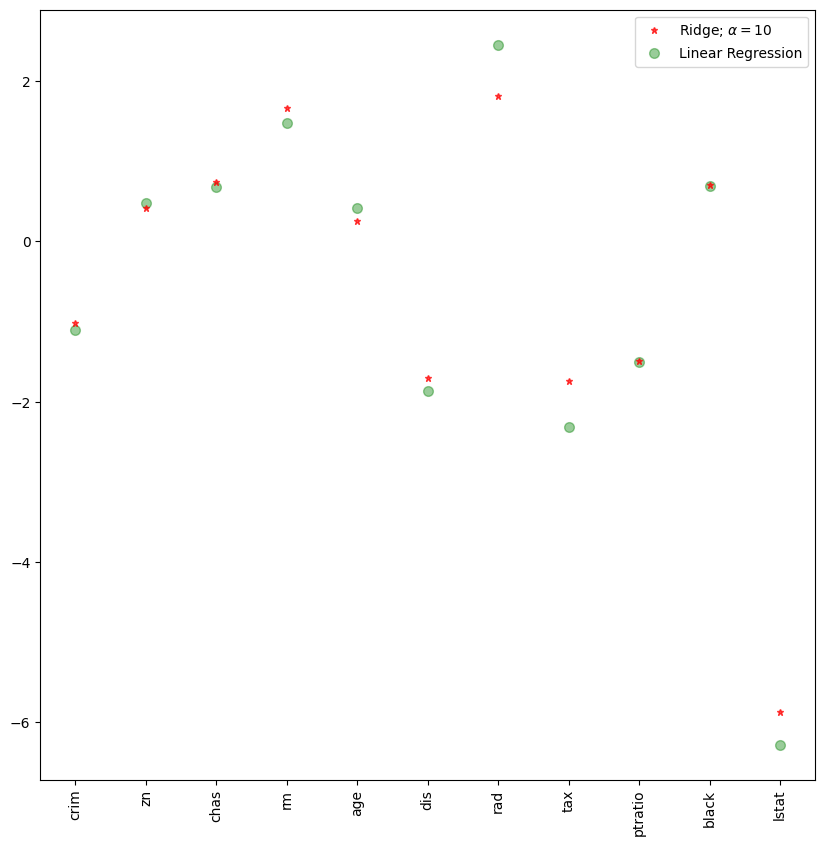

In [14]:
plt.figure(figsize = (10, 10))
plt.plot(features, ridgeReg.coef_, alpha=0.7, linestyle='none', marker='*', markersize=5, color='red', label=r'Ridge; $\alpha = 10$', zorder=7)
plt.plot(features, lr.coef_, alpha=0.4, linestyle='none', marker='o', markersize=7, color='green', label='Linear Regression')
plt.xticks(rotation = 90)
plt.legend()
plt.show()


In [16]:
#Lasso regression model
print("\nLasso Model............................................\n")
lasso = Lasso(alpha = 10)
lasso.fit(X_train,y_train)
train_score_ls =lasso.score(X_train,y_train)
test_score_ls =lasso.score(X_test,y_test)

print("The train score for ls model is {}".format(train_score_ls))
print("The test score for ls model is {}".format(test_score_ls))



Lasso Model............................................

The train score for ls model is 0.0
The test score for ls model is -0.0030704836212473996


In [17]:
print(lasso.coef_)

[-0.  0.  0.  0. -0.  0. -0. -0. -0.  0. -0.]


<Axes: >

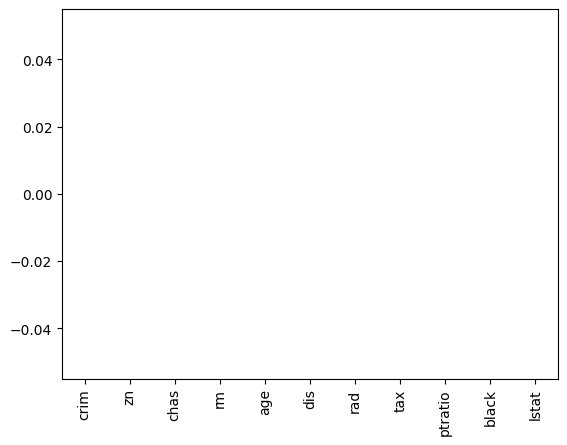

In [10]:
pd.Series(lasso.coef_, features).sort_values(ascending = True).plot(kind = "bar")


In [ ]:
#Using the linear CV model
from sklearn.linear_model import LassoCV

#Lasso Cross validation
lasso_cv = LassoCV(alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10], random_state=0).fit(X_train, y_train)

# Print the range of alpha values
print([10**x for x in np.arange(-5, 5, 0.5)])

print(lasso_cv.alpha_)
#score
print(lasso_cv.score(X_train, y_train))
print(lasso_cv.score(X_test, y_test))


[np.float64(1e-05), np.float64(3.1622776601683795e-05), np.float64(0.0001), np.float64(0.00031622776601683794), np.float64(0.001), np.float64(0.0031622776601683794), np.float64(0.01), np.float64(0.03162277660168379), np.float64(0.1), np.float64(0.31622776601683794), np.float64(1.0), np.float64(3.1622776601683795), np.float64(10.0), np.float64(31.622776601683793), np.float64(100.0), np.float64(316.22776601683796), np.float64(1000.0), np.float64(3162.2776601683795), np.float64(10000.0), np.float64(31622.776601683792)]
0.0001
0.7859187081843189
0.7672374265750733


In [19]:
#Lasso regression model
print("\nLasso Model............................................\n")
lasso = Lasso(alpha = 0.0001)
lasso.fit(X_train,y_train)
train_score_ls =lasso.score(X_train,y_train)
test_score_ls =lasso.score(X_test,y_test)

print(lasso.coef_)

print("The train score for ls model is {}".format(train_score_ls))
print("The test score for ls model is {}".format(test_score_ls))



Lasso Model............................................

[-1.10288219  0.47523504  0.67886649  1.47139967  0.42047242 -1.86894077
  2.4531386  -2.31763129 -1.50335353  0.69398636 -6.27769257]
The train score for ls model is 0.7859187081843189
The test score for ls model is 0.7672374265750733


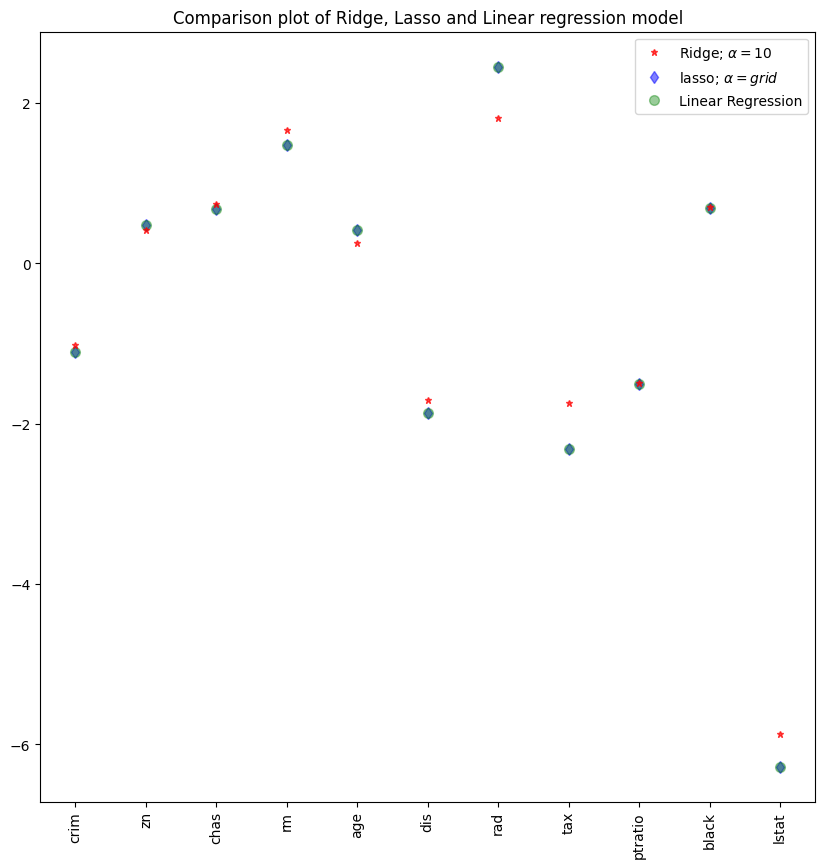

In [12]:
#plot size
plt.figure(figsize = (10, 10))
#add plot for ridge regression
plt.plot(features,ridgeReg.coef_,alpha=0.7,linestyle='none',marker='*',markersize=5,color='red',label=r'Ridge; $\alpha = 10$',zorder=7)

#add plot for lasso regression
plt.plot(lasso_cv.coef_,alpha=0.5,linestyle='none',marker='d',markersize=6,color='blue',label=r'lasso; $\alpha = grid$')

#add plot for linear model
plt.plot(features,lr.coef_,alpha=0.4,linestyle='none',marker='o',markersize=7,color='green',label='Linear Regression')

#rotate axis
plt.xticks(rotation = 90)
plt.legend()
plt.title("Comparison plot of Ridge, Lasso and Linear regression model")
plt.show()


In [13]:
#Using the linear CV model
from sklearn.linear_model import RidgeCV

#Lasso Cross validation
ridge_cv = RidgeCV(alphas = [0.0001, 0.001,0.01, 0.1, 1, 10]).fit(X_train, y_train)

print(ridge_cv.alpha_)

#score
print("The train score for ridge model is {}".format(ridge_cv.score(X_train, y_train)))
print("The train score for ridge model is {}".format(ridge_cv.score(X_test, y_test)))

1.0
The train score for ridge model is 0.7858973065951276
The train score for ridge model is 0.7676510554851331
